# BigMart Sales Prediction using Machine Learning

# Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

# Data Collection and Loading

In [2]:
bigMart = pd.read_csv("/content/Train (2).csv")

# Data Understanding

In [3]:
bigMart.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# some info
bigMart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
bigMart.isnull().mean()*100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


In [ ]:
bigMart['Item_Weight'].mean()

np.float64(12.857645184135976)

# Handling Missing Values


In [ ]:
bigMart['Item_Weight'].fillna(bigMart['Item_Weight'].mean(), inplace = True)

/tmp/ipykernel_4241/1290367762.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bigMart['Item_Weight'].fillna(bigMart['Item_Weight'].mean(), inplace = True)


In [ ]:
bigMart['Outlet_Size'].unique()

array(['Medium', nan, 'High', 'Small'], dtype=object)

In [ ]:
# Creating a pivot table to find the most frequent (mode) Outlet_Size
# for each Outlet_Type category
mode_of_outlet_size = bigMart.pivot_table(
    values='Outlet_Size',
    columns='Outlet_Type',
    aggfunc=(lambda x : x.mode()[0])
)

In [ ]:
mode_of_outlet_size

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [ ]:
missing_val = bigMart['Outlet_Size'].isnull()

In [ ]:
missing_val

,Outlet_Size
0,False
1,False
2,False
3,True
4,False
...,...
8518,False
8519,True
8520,False
8521,False


In [ ]:
# fill missing Outlet_Size values based on Outlet_Type mode

bigMart.loc[missing_val, 'Outlet_Size'] = (
    bigMart.loc[missing_val, 'Outlet_Type']
    .apply(lambda x: mode_of_outlet_size[x])
)

In [ ]:
bigMart.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
bigMart.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


# Data Visualization


In [ ]:
# Apply seaborn default styling to make plots more attractive and readable
sns.set()

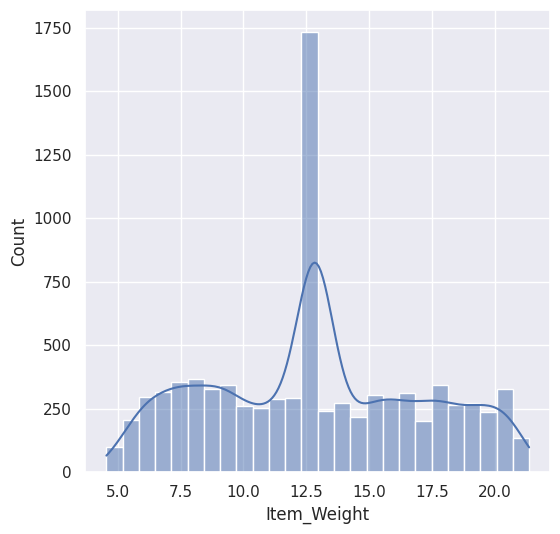

In [ ]:
plt.figure(figsize=(6,6))
# Plot histogram with density curve
sns.histplot(bigMart['Item_Weight'], kde=True)
plt.show()

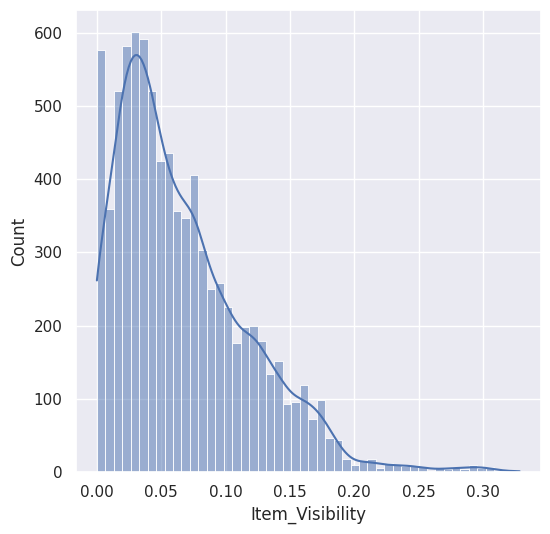

In [ ]:
# Item_Visibility distriution
plt.figure(figsize=(6,6))
sns.histplot(bigMart['Item_Visibility'], kde=True)
plt.show()

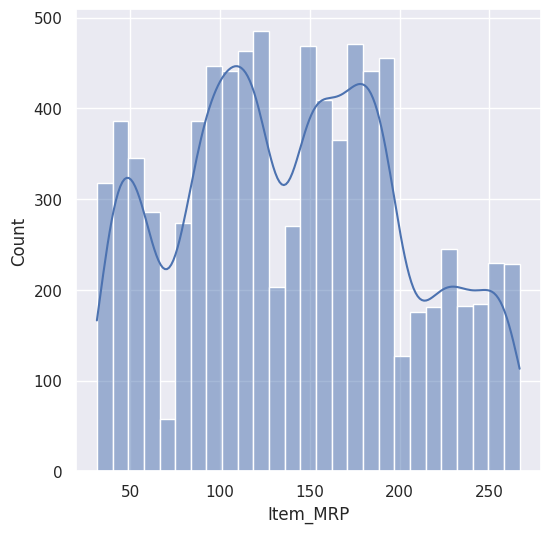

In [ ]:
# Item_MRP distriution
plt.figure(figsize=(6,6))
sns.histplot(bigMart['Item_MRP'], kde=True)
plt.show()

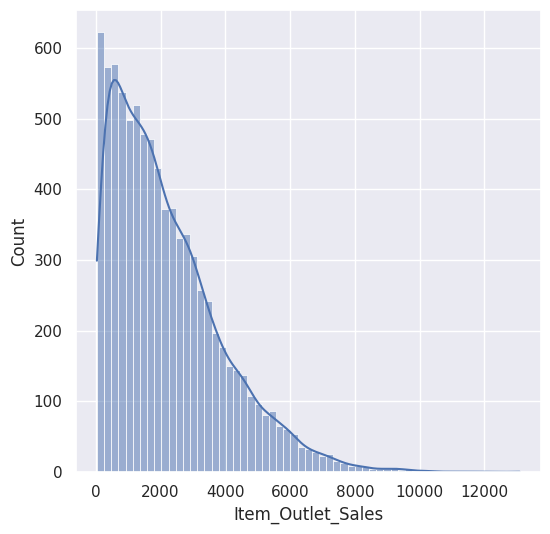

In [ ]:
# Item_Outlet_Sales distriution
plt.figure(figsize=(6,6))
sns.histplot(bigMart['Item_Outlet_Sales'], kde=True)
plt.show()

<Axes: xlabel='Item_Outlet_Sales'>

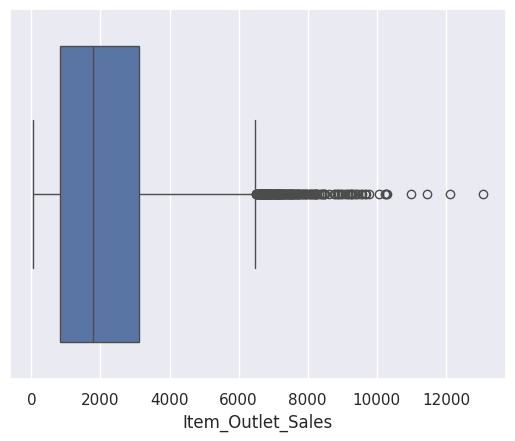

In [ ]:
# boxplot to detect outliers in Item_Outlet_Sales

sns.boxplot(x=bigMart['Item_Outlet_Sales'])

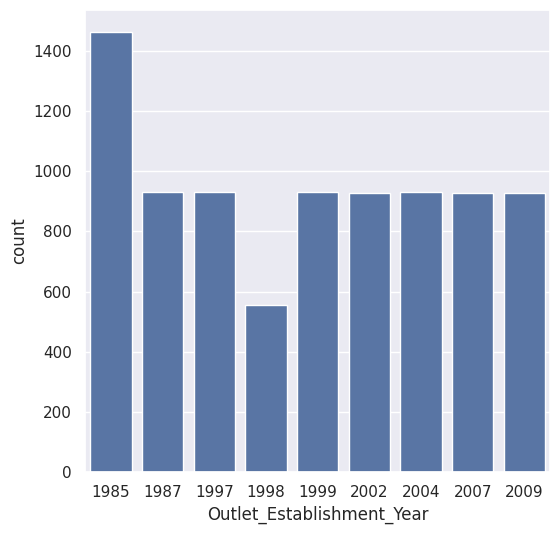

In [ ]:
# Outlet_Establishment_Year col
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year', data=bigMart)
plt.show()

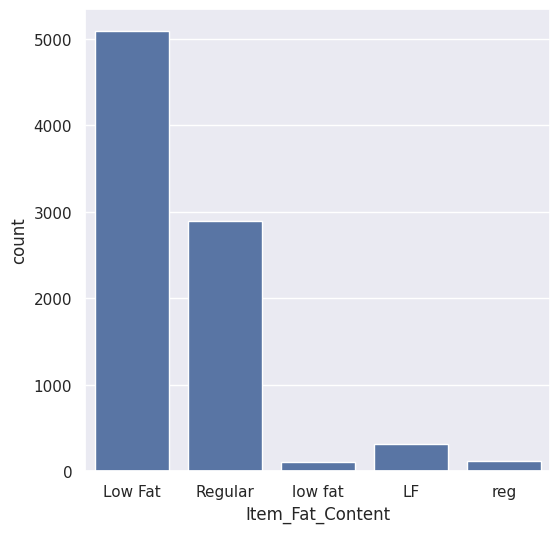

In [ ]:
# Item_Fat_Content col
plt.figure(figsize=(6,6))
sns.countplot(x='Item_Fat_Content', data=bigMart)
plt.show()

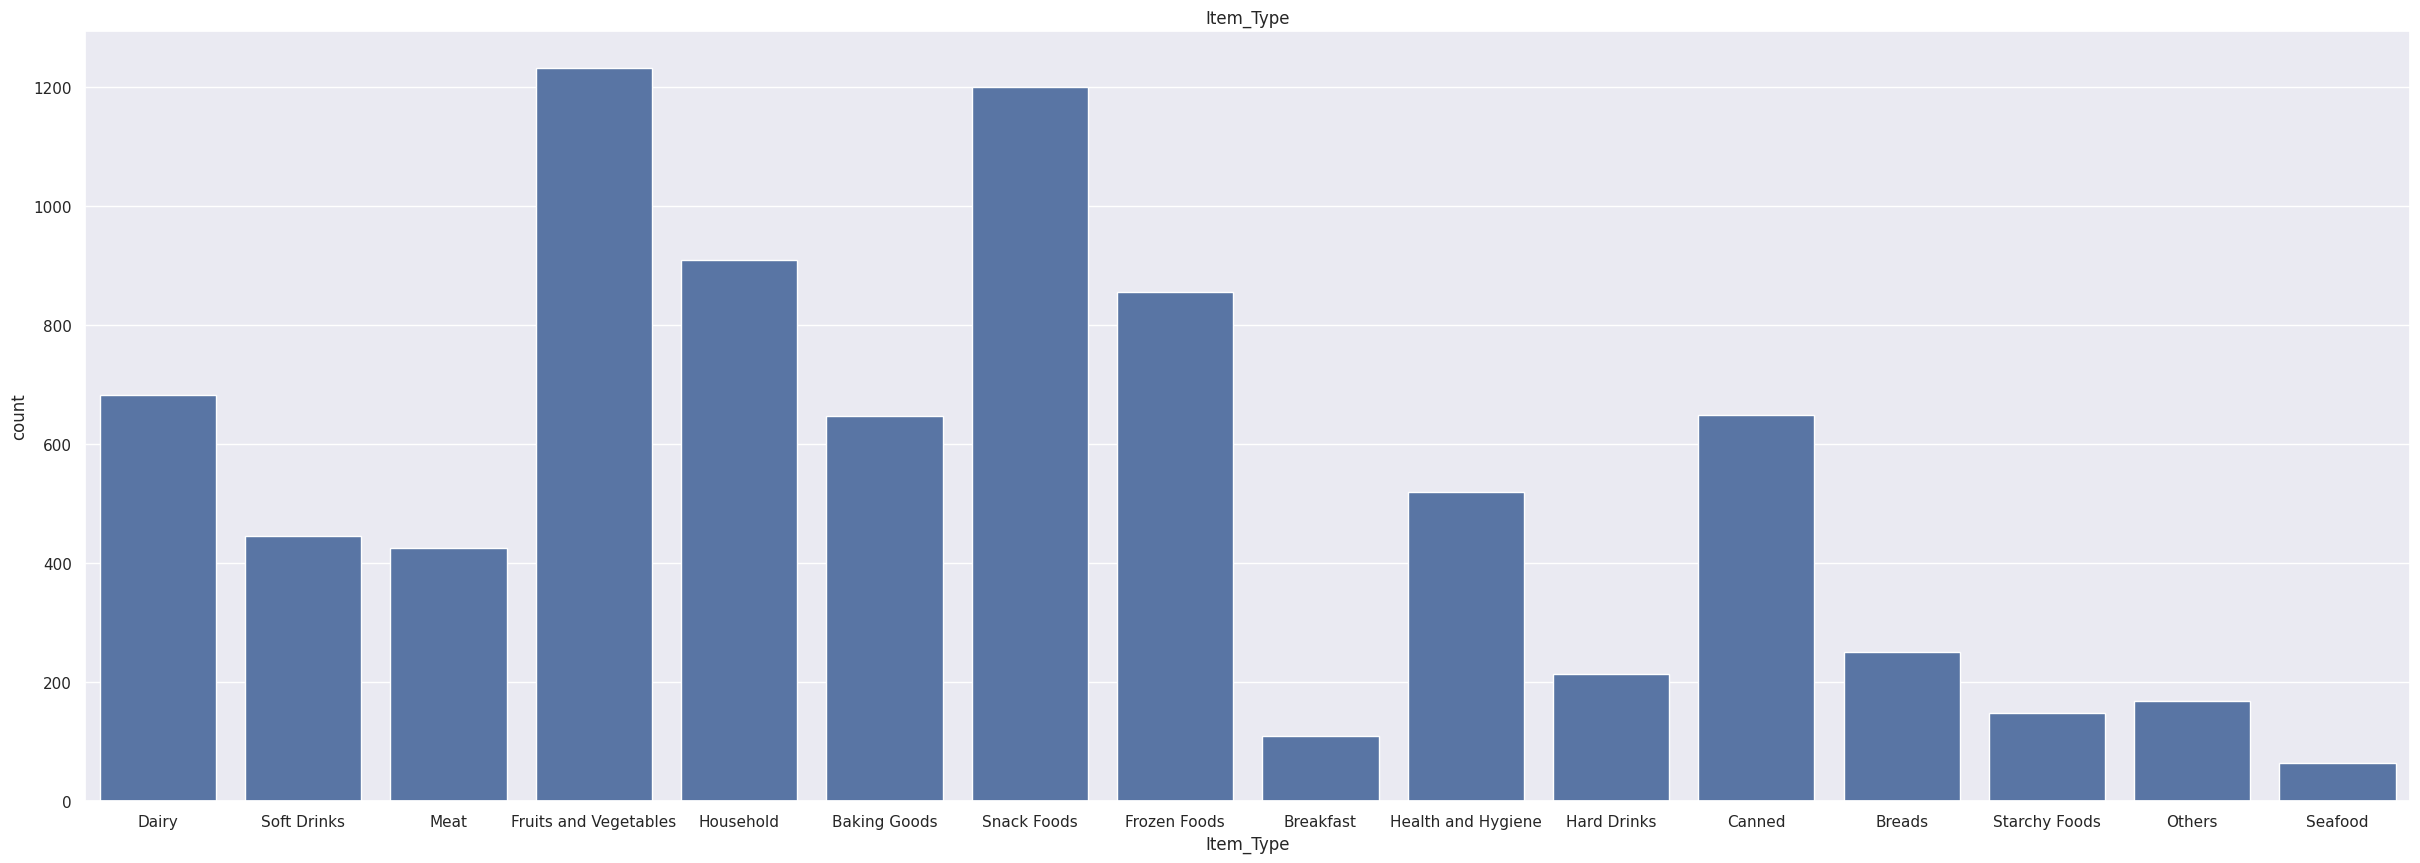

In [ ]:
# Item_Type col
plt.figure(figsize=(30,10))
sns.countplot(x='Item_Type', data=bigMart)
plt.title('Item_Type')
plt.show()

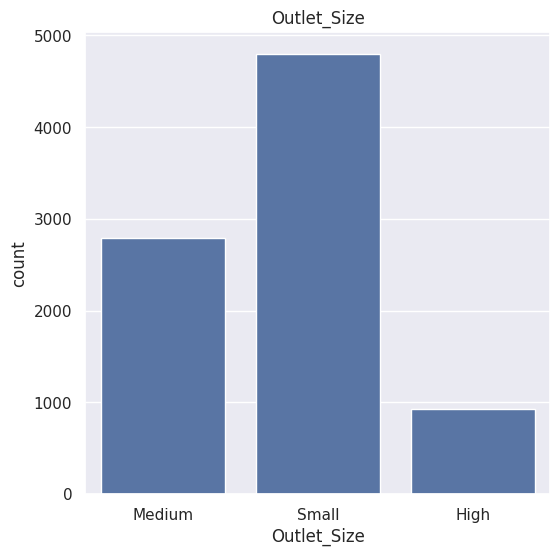

In [ ]:
# Outlet_Size col
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Size', data=bigMart)
plt.title('Outlet_Size')
plt.show()

In [ ]:
bigMart.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
6503,FDT45,15.850000,Low Fat,0.000000,Snack Foods,55.1956,OUT013,1987,High,Tier 3,Supermarket Type1,1255.6988
6706,NCO26,7.235000,Low Fat,0.077011,Household,117.3492,OUT045,2002,Small,Tier 2,Supermarket Type1,1506.0396
4478,FDL34,12.857645,Low Fat,0.040748,Snack Foods,140.2496,OUT027,1985,Medium,Tier 3,Supermarket Type3,4093.3384
5866,NCW18,15.100000,Low Fat,0.059275,Household,238.9248,OUT013,1987,High,Tier 3,Supermarket Type1,6636.6944
2610,NCB54,8.760000,Low Fat,0.050257,Health and Hygiene,127.3336,OUT018,2009,Medium,Tier 3,Supermarket Type2,2684.5056


In [ ]:
bigMart['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [ ]:
# Replace inconsistent category labels in Item_Fat_Content column
# to make the data standardized and consistent
bigMart.replace({
    'Item_Fat_Content': {
        'low fat': 'Low Fat',
        'LF': 'Low Fat',
        'reg': 'Regular'
    }
}, inplace=True)

In [ ]:
bigMart['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


# Data Encoding

In [ ]:
encoder = LabelEncoder()

In [ ]:
# Convert categorical text columns into numerical values
# using Label Encoding for machine learning models

bigMart['Item_Identifier'] = encoder.fit_transform(bigMart['Item_Identifier'])
bigMart['Item_Fat_Content'] = encoder.fit_transform(bigMart['Item_Fat_Content'])
bigMart['Item_Type'] = encoder.fit_transform(bigMart['Item_Type'])
bigMart['Outlet_Identifier'] = encoder.fit_transform(bigMart['Outlet_Identifier'])
bigMart['Outlet_Size'] = encoder.fit_transform(bigMart['Outlet_Size'])
bigMart['Outlet_Location_Type'] = encoder.fit_transform(bigMart['Outlet_Location_Type'])
bigMart['Outlet_Type'] = encoder.fit_transform(bigMart['Outlet_Type'])

In [ ]:
bigMart.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3141,439,10.500000,0,0.052637,5,88.5830,9,1999,1,0,1,808.9470
3440,950,12.857645,0,0.167725,5,128.3678,4,1985,2,0,0,127.1678
6294,870,7.825000,0,0.079614,10,65.0826,6,2004,2,1,1,1162.4868
708,1149,14.300000,1,0.049635,10,212.5586,1,1987,0,2,1,3165.8790
4367,714,17.700000,0,0.029933,13,169.0816,6,2004,2,1,1,5201.2296


# Feature and Target Separation


In [ ]:
X = bigMart.drop(columns='Item_Outlet_Sales', axis=1)
Y = bigMart['Item_Outlet_Sales']

In [ ]:
X.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1


In [ ]:
Y.head(5)

,Item_Outlet_Sales
0,3735.1380
1,443.4228
2,2097.2700
3,732.3800
4,994.7052


# Splitting Training and Testing Data


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(8523, 11) (6818, 11) (1705, 11)


# Model Training using XGBoost Regressor

In [ ]:
# XGBoost Regressor model with tuned hyperparameters
# n_estimators=300 → total number of trees
# max_depth=3 → controls tree depth to reduce overfitting
# learning_rate=0.05 → slow learning for better generalization
# subsample=0.8 → uses 80% data randomly for each tree
# colsample_bytree=0.8 → uses 80% features randomly for each tree
# reg_alpha=1 → L1 regularization to reduce complexity
# reg_lambda=1 → L2 regularization to prevent overfitting
# random_state=2 → ensures reproducible results

reg = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=2
)

In [ ]:
reg.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# predict on Training
training_data_pred = reg.predict(X_train)

# Model Evaluation



In [ ]:
# Calculate R-squared score to measure how well
# the model predictions match the actual training values
r2_train = metrics.r2_score(Y_train, training_data_pred)

In [ ]:
print(f"R squared score on training data: {r2_train}")

R squared score on training data: 0.6463203606457109


In [ ]:
# predict on test data
test_data_pred = reg.predict(X_test)

In [ ]:
r2_test = metrics.r2_score(Y_test, test_data_pred)

In [ ]:
print(f"R squared score on test data: {r2_test}")

R squared score on test data: 0.586710026537459


Conclusion:
The XGBoost Regressor model was trained and optimized using hyperparameter tuning techniques. Overfitting was reduced by controlling model complexity and applying regularization. The final model achieved balanced training and testing R² scores, showing good generalization performance.